# LTI CRN NETWORKS

In [1]:
from lrn_builder.siso_analyzer import SISOAnalyzer
from lrn_builder.make_lti_crn import makeLtiCrn  # type: ignore

import numpy as np
import pandas as pd
import tellurium as te
import matplotlib.pyplot as plt
from scipy import signal

# Making LTI Networks

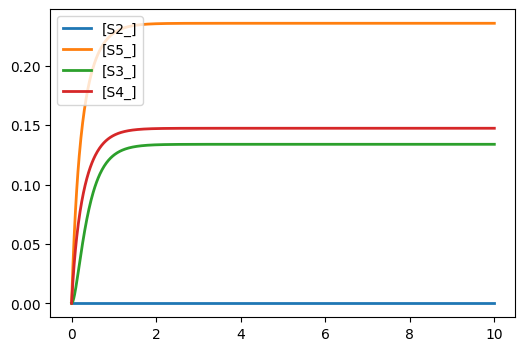

eigenvalues: [-13.17295814  -3.07282569  -9.49021618  -1.4417    ]
# Random Chemical Reaction Network
# Generated with specified constraints

model random_crn()

  species S1_;

  S2_ -> S5_ + 3 S3_ + 2 S5_; k2 * S2_
  S2_ -> S3_ + S4_ + 2 S4_ + 3 S4_; k3 * S2_
  S5_ -> 2 S5_ + 2 S5_ + 2 S4_ + 2 S3_; k4 * S5_
  S3_ -> S5_; k5 * S3_
  S3_ -> S4_ + 3 S5_ + 2 S5_ + 3 S4_ + 3 S4_; k6 * S3_
  S2_ -> S5_ + S5_ + 2 S4_ + 3 S4_; k7 * S2_
  S1_ -> 3 S5_ + S5_ + 3 S4_ + S5_; k8 * S1_
  S5_ -> 2 S3_ + 2 S4_ + 3 S5_; k9 * S5_
  S4_ -> S4_ + S3_; k10 * S4_

  # Rate constants
  k2 = 0.5338
  k3 = 0.4682
  k4 = 0.7512
  k5 = 0.4826
  k6 = 0.5016
  k7 = 0.4397
  k8 = 0.2229
  k9 = 0.8956
  k10 = 0.4710

  # Species initialization
  $S1_ = 1  # Input boundary species
  S2_ = 0
  S3_ = 0
  S4_ = 0
  S5_ = 0


  # Degradation reactions
  S5_ -> ; kd_1 * S5_
  kd_1 = 10.4678
  S3_ -> ; kd_2 * S3_
  kd_2 = 5.3350
  S4_ -> ; kd_3 * S4_
  kd_3 = 12.9938
end


In [9]:
MODEL = makeLtiCrn(num_species=5,
    num_reaction=10,
    num_products_bounds=[1, 5],
    kinetic_constant_bounds= (0.1, 1),
    stoichiometry_bounds=[1, 3],
    is_input_boundary=True)
rr = te.loada(MODEL)
DATA = rr.simulate(0, 10, 1000)
rr.plot()
mat = rr.getFullJacobian()
print(f"eigenvalues: {np.linalg.eigvals(mat)}")
print(MODEL)

# SISO Analysis

In [10]:
analyzer = SISOAnalyzer(MODEL, input_name="S1_")


In [11]:
tf = analyzer.makeTransferFunction()
print(tf)

TransferFunctionContinuous(
array([ 1.1145   , 21.5243385, 90.6108442]),
array([  1.        ,  25.736     , 194.6542046 , 384.14690793]),
dt: None
)


In [12]:
analyzer.transfer_function_smat

Matrix([
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        1.0],
[                                                                                                                                                               

In [13]:
tf.poles

array([-13.17295814,  -9.49021618,  -3.07282569])

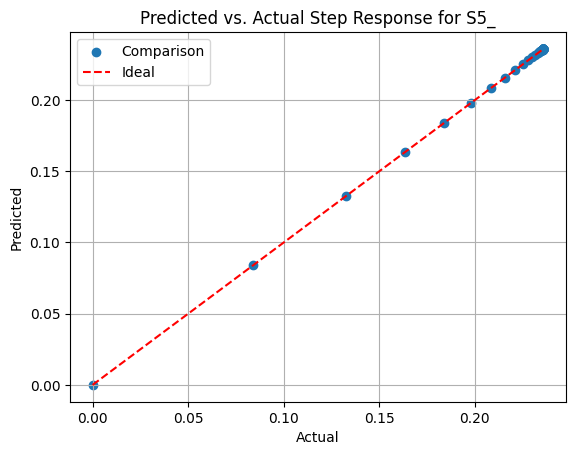

In [14]:
analyzer.plotTransferFunctionValidation()

In [15]:
tf_smat = analyzer.transfer_function_smat
tf_smat

Matrix([
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        1.0],
[                                                                                                                                                               